# Week 11 Lab 2 - Reconstruct velocity, then identify vortices

<!-- FlowMLLab retained-LBM reconstruction audit v1 -->

Read [the complete experimental protocol](RECONSTRUCTION_PROTOCOL.md) first.
This is an independent compact U-Net implementation inspired by the supplied
super-resolution course material, not a reproduction of its code or results.
The real LBM wake has no shocks. Masks are velocity-derived weak references.
Run All audits the retained run without modifying it. Full retraining is an
explicit opt-in below; it requires CPU PyTorch and takes longer than this audit.

<!-- FLOWMLLAB_COLAB_LAUNCH_V1 -->
[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/Ehsan-Roohi/FlowMLLab/blob/main/notebooks/week11/W11_Lab2_Reconstruction_and_Identification.ipynb)


In [1]:
# FLOWMLLAB_COLAB_BOOTSTRAP_V1
# In Colab this cell obtains the complete repository and installs the tested package.
# In a local checkout it leaves the active environment and working directory unchanged.
from pathlib import Path as _FlowMLLabPath
import os as _flowmllab_os
import subprocess as _flowmllab_subprocess
import sys as _flowmllab_sys

if "google.colab" in _flowmllab_sys.modules or _flowmllab_os.environ.get("COLAB_RELEASE_TAG"):
    _flowmllab_root = _FlowMLLabPath("/content/FlowMLLab")
    if not (_flowmllab_root / ".git").is_dir():
        _flowmllab_subprocess.run(
            [
                "git", "clone", "--depth", "1",
                "https://github.com/Ehsan-Roohi/FlowMLLab.git", str(_flowmllab_root),
            ],
            check=True,
        )
    _flowmllab_subprocess.run(
        [
            _flowmllab_sys.executable, "-m", "pip", "install", "-q", "-e",
            f"{_flowmllab_root}[test]",
        ],
        check=True,
    )
    _flowmllab_notebook_dir = _flowmllab_root / "notebooks/week11"
    _flowmllab_os.chdir(_flowmllab_notebook_dir)
    for _flowmllab_path in (_flowmllab_root, _flowmllab_notebook_dir):
        if str(_flowmllab_path) not in _flowmllab_sys.path:
            _flowmllab_sys.path.insert(0, str(_flowmllab_path))
    print("FlowMLLab ready:", _flowmllab_root)

from pathlib import Path
import hashlib, json, sys
ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / 'flowmllab/modal_experiments.py').is_file())
sys.path.insert(0, str(ROOT))
from flowmllab.modal_experiments import load_cases
cases = load_cases(ROOT / 'data/modal_labs')
evidence = ROOT / 'results/week11_reconstruction'
manifest = json.loads((evidence / 'manifest.json').read_text())
for name, digest in manifest.items():
    assert hashlib.sha256((evidence / name).read_bytes()).hexdigest() == digest, name
protocol = json.loads((evidence / 'protocol.json').read_text())
assert protocol['train'] == [90, 110]
assert protocol['validation'] == 100 and protocol['retained_test'] == 105
assert protocol['data_manifest_sha256'] == hashlib.sha256((ROOT / 'data/modal_labs/manifest.json').read_bytes()).hexdigest()
print(protocol['scope'])


Previously inspected coarse incompressible LBM; no shock accuracy claim


## Separate field accuracy from structure agreement

Velocity MSE does not optimize derivatives or binary masks. Compare vorticity
error as well as velocity error. Dice and IoU quantify agreement with the same
native-ROI swirling-strength rule, not human-validated vortex accuracy.
Direct segmentation has no reconstructed field, hence its field metrics are N/A.
The three seeds measure optimizer variation, not uncertainty over new flows.


In [2]:
import pandas as pd
metrics = pd.DataFrame(json.loads((evidence / 'metrics.json').read_text()))
display(metrics)
display(metrics.groupby('method')[['velocity_relative_l2','vorticity_relative_l2','dice','iou']].agg(['mean','std']))


,method,seed,velocity_relative_l2,vorticity_relative_l2,divergence_rms,dice,iou,selected_epoch,parameters,probability_threshold
0,Interpolation,NaN,0.078864,0.398007,0.048670,0.773036,0.630512,NaN,NaN,NaN
1,reconstruction,17.0,0.017696,0.112204,0.031786,0.947674,0.900755,59.0,29698.0,NaN
2,segmentation,17.0,NaN,NaN,NaN,0.967259,0.936752,58.0,29689.0,0.55
3,reconstruction,29.0,0.018910,0.126100,0.032927,0.941913,0.890391,57.0,29698.0,NaN
4,segmentation,29.0,NaN,NaN,NaN,0.972734,0.947043,57.0,29689.0,0.55
5,reconstruction,43.0,0.020904,0.140697,0.032095,0.940873,0.888613,58.0,29698.0,NaN
6,segmentation,43.0,NaN,NaN,NaN,0.971840,0.945367,60.0,29689.0,0.45


velocity_relative_l2           vorticity_relative_l2            \
                               mean       std                  mean       std   
method                                                                          
Interpolation              0.078864       NaN              0.398007       NaN   
reconstruction             0.019170  0.001619              0.126334  0.014248   
segmentation                    NaN       NaN                   NaN       NaN   

                    dice                 iou            
                    mean       std      mean       std  
method                                                  
Interpolation   0.773036       NaN  0.630512       NaN  
reconstruction  0.943487  0.003664  0.893253  0.006557  
segmentation    0.970611  0.002937  0.943054  0.005522

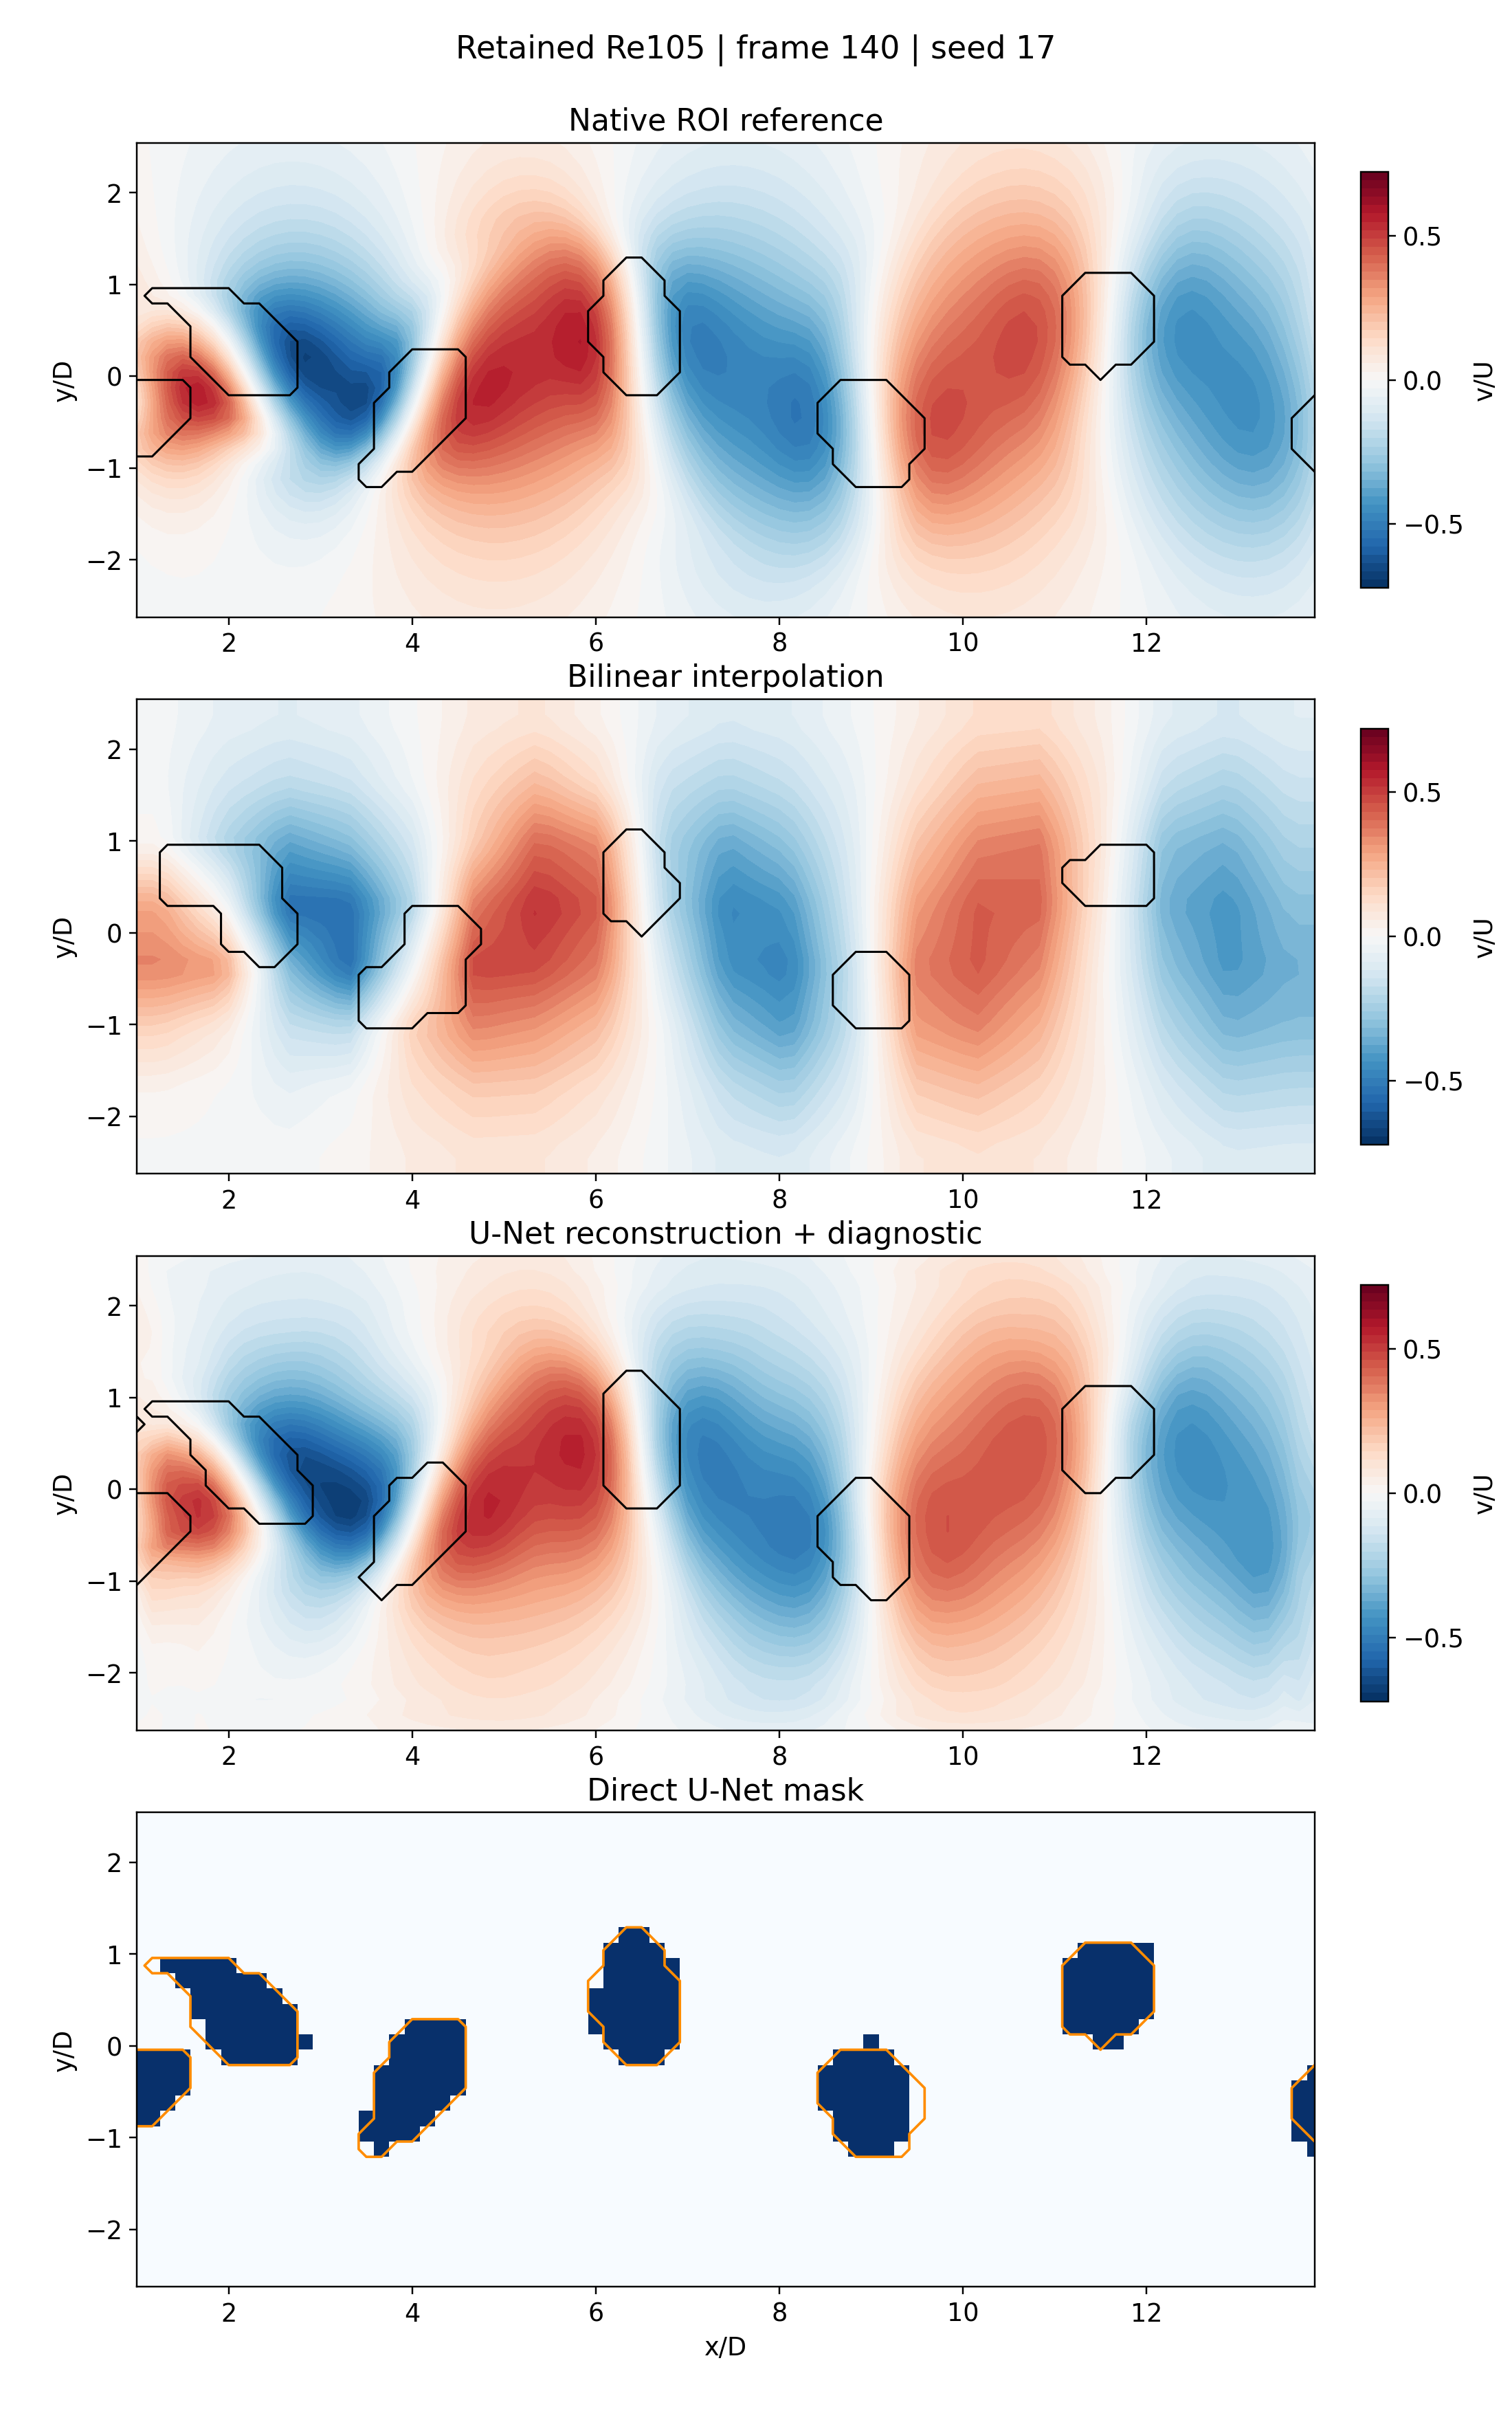

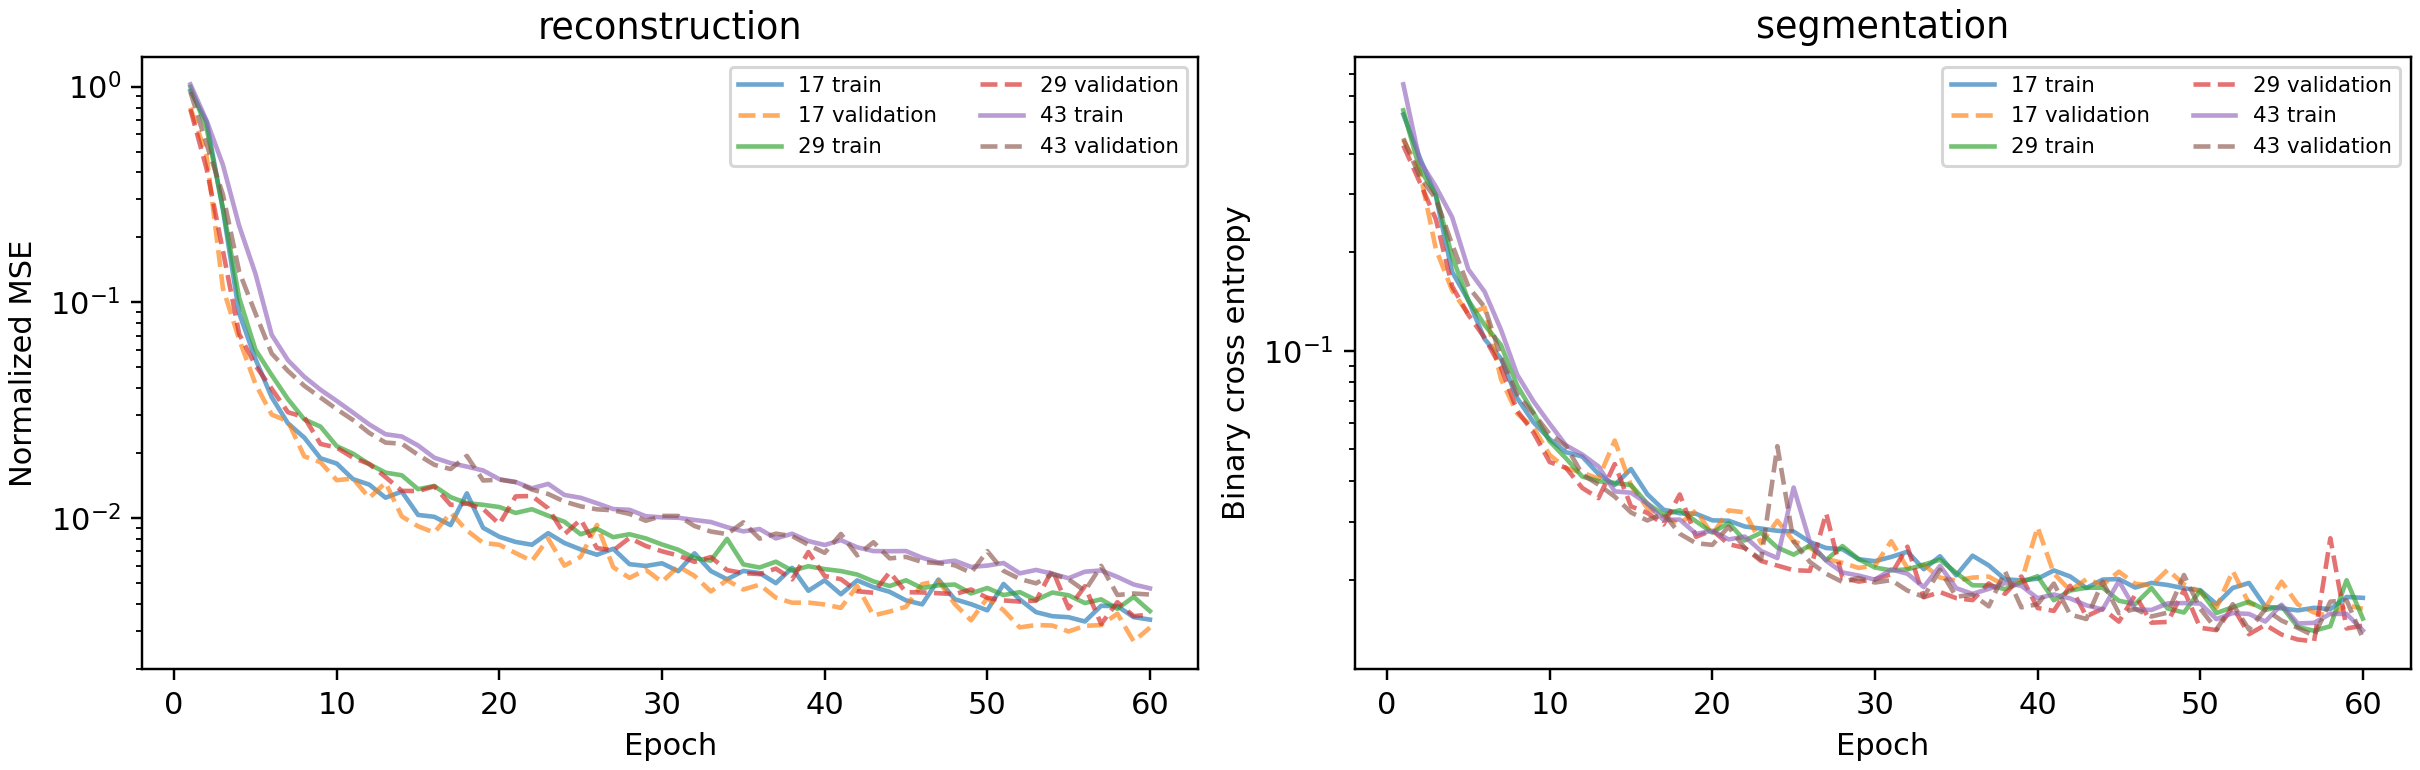

In [3]:
from IPython.display import Image, display
display(Image(filename=str(evidence / 'comparison.png'), width=1100))
display(Image(filename=str(evidence / 'loss.png'), width=1100))


## Fresh training (optional)

Set `RETRAIN=True` to train all six models into a new scratch folder. Install
PyTorch for your platform first. Do not lower the budget and label the result
as the retained experiment. Both neural paths see identical degraded inputs.
The original course network had more encoder levels and a different dataset;
this compact model is an adaptation, not a claim of exact replication.


In [4]:
RETRAIN = False
if RETRAIN:
    import subprocess, tempfile
    scratch = Path(tempfile.mkdtemp(prefix='flowmllab_w11_')) / 'run'
    subprocess.run([sys.executable, str(ROOT / 'qa/run_week11_reconstruction.py'),
                    '--output', str(scratch), '--epochs', '60'], check=True)
    print('Fresh evidence:', scratch)


## Research questions

1. Does the lowest velocity error necessarily yield the highest mask Dice?
2. Why can the divergence RMS differ from zero for the native coarse ROI?
3. What changes if the diagnostic threshold is varied using training/validation
   cases only? Freeze that experiment before evaluating Re105 again.
4. Which additional reference data would be needed to claim shock detection,
   rather than incompressible vortex recovery?

Do not select a seed, frame or probability threshold using the retained test.
